# SWOT Raster (full pipeline)

In [253]:
%load_ext autoreload
%autoreload 2

import earthaccess
import geopandas as gpd
import rioxarray as xrio
import xarray as xr

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.swot import (
    auth_earthaccess,
    create_mosaic_df,
    get_swot_footprint,
    search_swot_data,
    swot_results_to_df,
    create_raster_mosaic,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
auth_earthaccess()

## Open the AOI

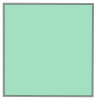

In [3]:
# Read geometry from a KML file
aois = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")
if aois is not None:
    aoi = aois[0]

aoi

## Search for SWOT Rasters

In [25]:
# Search for products within the AOI and Time frame
results = search_swot_data(
    dataset="Raster_100",
    date_range=("2024-01-01", "2025-11-30"),
    aoi=aoi,
    footprint_filter=True,  # Apply footprint filter to ensure granules intersect with AOI
)

len(results)

16

In [23]:
results[0]

Collection: {'Version': 'D', 'ShortName': 'SWOT_L2_HR_Raster_D'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -2.2066260684515955, 'Longitude': -53.771517490119656}, {'Latitude': -2.374540006836841, 'Longitude': -54.91010365727908}, {'Latitude': -3.519923595260316, 'Longitude': -54.74336765724447}, {'Latitude': -3.3516831748054012, 'Longitude': -53.60369840974684}, {'Latitude': -2.2066260684515955, 'Longitude': -53.771517490119656}]}}], 'BoundingRectangles': [{'WestBoundingCoordinate': -54.91010365727908, 'SouthBoundingCoordinate': -3.519923595260316, 'EastBoundingCoordinate': -53.60369840974684, 'NorthBoundingCoordinate': -2.2066260684515955}]}, 'Track': {'Cycle': 32, 'Passes': [{'Pass': 186, 'Tiles': ['158L', '159L', '160L', '161L', '158R', '159R', '160R', '161R']}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-05-04T15:55:38.365Z', 'BeginningDateTime': '2025-05-04T15:55:17.280Z'}}
Size(MB): 28.873699188232422
Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_D/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_032_186_080F_20250504T155517_20250504T155538_PIC2_01.nc']

In [26]:
swot_df = swot_results_to_df(results, drop_duplicates=True)
len(swot_df)

12

In [27]:
mosaic_df = create_mosaic_df(swot_df, max_delta=30)
mosaic_df

cycle_id pass_id tile_id         date_str  vers  \
mosaic_date tile_name                                                   
2025-05-22  033_075F       033     033    075F  20250520T012722  PID0   
            186_080F       033     186    080F  20250525T124023  PID0   
2025-06-12  033_075F       034     033    075F  20250609T221227  PID0   
            186_080F       034     186    080F  20250615T092527  PID0   
2025-07-03  033_075F       035     033    075F  20250630T185733  PID0   
            186_080F       035     186    080F  20250706T061033  PID0   
2025-07-13  033_075F       036     033    075F  20250721T154239  PID0   
            186_080F       035     186    080F  20250706T061033  PID0   
2025-08-14  033_075F       037     033    075F  20250811T122742  PID0   
            186_080F       037     186    080F  20250816T234042  PID0   
2025-09-04  033_075F       038     033    075F  20250901T091248  PID0   
            186_080F       038     186    080F  20250906T202547  PID0   

                                                                    item  \
mosaic_date tile_name                                                      
2025-05-22  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2025-06-12  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2025-07-03  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2025-07-13  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2025-08-14  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2025-09-04  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   

                                 datetime        date            delta  
mosaic_date tile_name                                                   
2025-05-22  033_075F  2025-05-20 01:27:22  2025-05-20  0 days 00:00:00  
            186_080F  2025-05-25 12:40:23  2025-05-25  5 days 11:13:01  
2025-06-12  033_075F  2025-06-09 22:12:27  2025-06-09  0 days 00:00:00  
            186_080F  2025-06-15 09:25:27  2025-06-15  5 days 11:13:00  
2025-07-03  033_075F  2025-06-30 18:57:33  2025-06-30  0 days 00:00:00  
            186_080F  2025-07-06 06:10:33  2025-07-06  5 days 11:13:00  
2025-07-13  033_075F  2025-07-21 15:42:39  2025-07-21  0 days 00:00:00  
            186_080F  2025-07-06 06:10:33  2025-07-06 15 days 09:32:06  
2025-08-14  033_075F  2025-08-11 12:27:42  2025-08-11  0 days 00:00:00  
            186_080F  2025-08-16 23:40:42  2025-08-16  5 days 11:13:00  
2025-09-04  033_075F  2025-09-01 09:12:48  2025-09-01  0 days 00:00:00  
            186_080F  2025-09-06 20:25:47  2025-09-06  5 days 11:12:59

<Axes: >

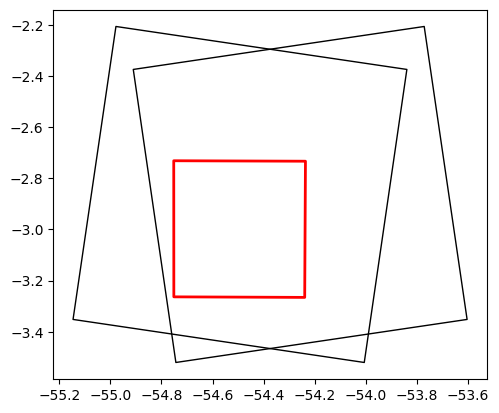

In [29]:
# Plot footprints vs AOI
# Create a DF for the AOI
aoi_df = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326")

mosaic = mosaic_df.loc["2025-05-22"]
footprints = [get_swot_footprint(item)[0] for item in mosaic["item"]]

footprints_df = gpd.GeoDataFrame(geometry=footprints, crs="EPSG:4326")
ax = aoi_df.plot(color="none", edgecolor="red", linewidth=2)
footprints_df.plot(ax=ax, color="none")

## Download single raster

In [33]:
raster_item = mosaic["item"].iloc[0]
raster_item

Collection: {'Version': 'D', 'ShortName': 'SWOT_L2_HR_Raster_D'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -3.3516831748054012, 'Longitude': -55.14578554225298}, {'Latitude': -3.519923595260316, 'Longitude': -54.00611629475535}, {'Latitude': -2.374539996837349, 'Longitude': -53.83938029472503}, {'Latitude': -2.2066260584520814, 'Longitude': -54.977966461876555}, {'Latitude': -3.3516831748054012, 'Longitude': -55.14578554225298}]}}], 'BoundingRectangles': [{'WestBoundingCoordinate': -55.14578554225298, 'SouthBoundingCoordinate': -3.519923595260316, 'EastBoundingCoordinate': -53.83938029472503, 'NorthBoundingCoordinate': -2.2066260584520814}]}, 'Track': {'Cycle': 33, 'Passes': [{'Pass': 33, 'Tiles': ['148L', '149L', '150L', '151L', '148R', '149R', '150R', '151R']}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-05-20T01:27:43.642Z', 'BeginningDateTime': '2025-05-20T01:27:22.552Z'}}
Size(MB): 38.550540924072266
Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_D/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_033_033_075F_20250520T012722_20250520T012743_PID0_01.nc']

In [34]:
raster_file = earthaccess.download([raster_item], local_path="/data/swot/downloads")
raster_file

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

['/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_033_033_075F_20250520T012722_20250520T012743_PID0_01.nc']

In [35]:
raster = xrio.open_rasterio(raster_file[0]).squeeze()
raster

<xarray.Dataset> Size: 325MB
Dimensions:                  (x: 1457, y: 1456)
Coordinates:
    band                     int64 8B 1
  * x                        (x) float64 12kB 7.06e+05 7.061e+05 ... 8.516e+05
  * y                        (y) float64 12kB 9.756e+06 9.756e+06 ... 9.61e+06
    crs                      int64 8B 0
Data variables: (12/38)
    longitude                (y, x) float64 17MB ...
    water_area_uncert        (y, x) float32 8MB ...
    water_frac               (y, x) float32 8MB ...
    water_frac_uncert        (y, x) float32 8MB ...
    sig0                     (y, x) float32 8MB ...
    sig0_qual                (y, x) uint8 2MB ...
    ...                       ...
    wse_qual                 (y, x) uint8 2MB ...
    wse_qual_bitwise         (y, x) uint32 8MB ...
    wse_uncert               (y, x) float32 8MB ...
    water_area               (y, x) float32 8MB ...
    water_area_qual          (y, x) uint8 2MB ...
    water_area_qual_bitwise  (y, x) uint32 8MB ...
Attributes: (12/49)
    contact:                       podaac@podaac.jpl.nasa.gov
    Conventions:                   CF-1.7
    coordinate_reference_system:   Universal Transverse Mercator
    crid:                          PID0
    cycle_number:                  33
    descriptor_string:             100m_UTM21M_N_x_x_x
    ...                            ...
    xref_param_l2_hr_raster_file:  SWOT_Param_L2_HR_Raster_20000101T000000_21...
    xref_reforbittrack_files:      SWOT_RefOrbitTrackTileBoundary_Nom_2000010...
    x_max:                         851600
    x_min:                         706000
    y_max:                         9755900
    y_min:                         9610400

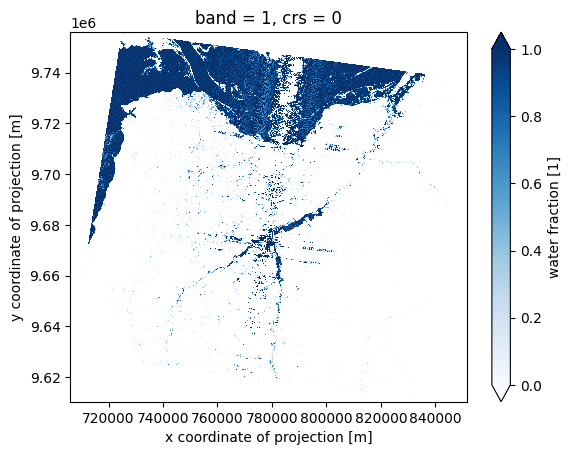

In [36]:
water_frac = raster["water_frac"]
water_frac = water_frac.where(water_frac.attrs["_FillValue"] != water_frac)
water_frac.plot(cmap="Blues", vmin=0, vmax=1)

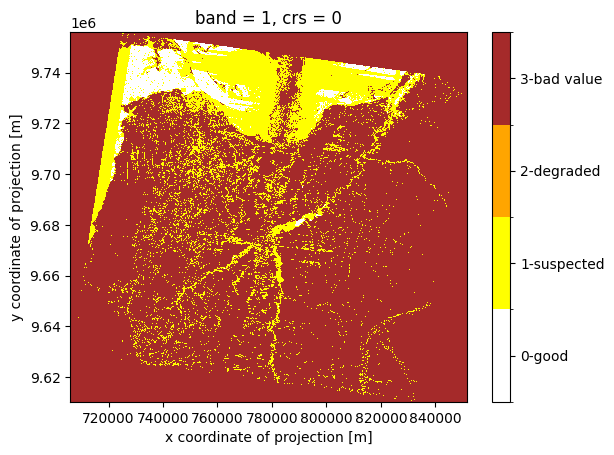

In [77]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define exactly 4 colors for your 4 categories
values = [0, 1, 2, 3]
labels = ["0-good", "1-suspected", "2-degraded", "3-bad value"]
colors = ["white", "yellow", "orange", "brown"]
cmap_listed = ListedColormap(colors)

# Create boundaries that center the values 0, 1, 2, 3
# Each value will be centered in its color segment
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

# Plot with discrete colorbar
im = raster["water_area_qual"].plot.imshow(
    cmap=cmap_listed,
    norm=norm,
    add_colorbar=False,  # We'll add a custom colorbar
)

# Add a custom colorbar with centered tick labels
cbar = plt.colorbar(im)
cbar.set_ticks(values)  # Set ticks at the actual values
cbar.set_ticklabels(labels)  # Descriptive labels

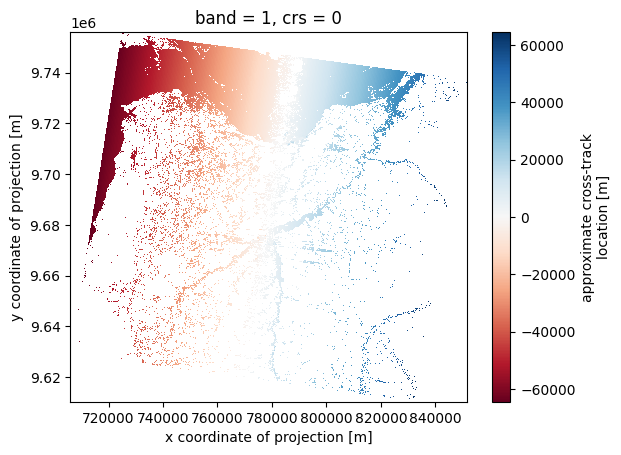

In [39]:
cross_track = raster["cross_track"]
cross_track = cross_track.where(cross_track.attrs["_FillValue"] != cross_track)
cross_track.plot(cmap="RdBu")

## Bit Flags

In [79]:
from swot_toolkit.flags import QUALITY_FLAGS, mask_by_flags

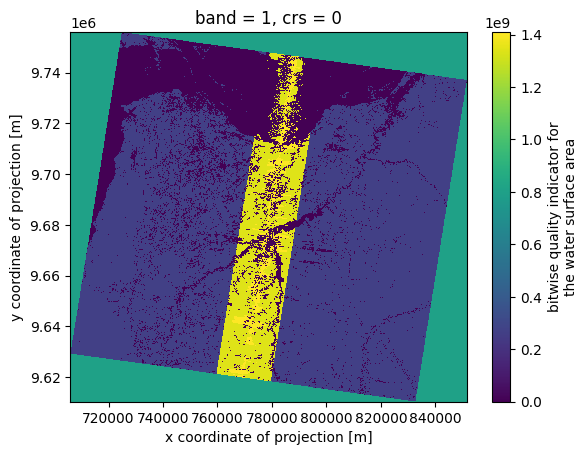

In [78]:
qual_bit = raster["water_area_qual_bitwise"]
qual_bit.plot()

In [80]:
len(QUALITY_FLAGS)

18

In [82]:
mask = mask_by_flags(qual_bit, flags=["classification_qual_suspect"])

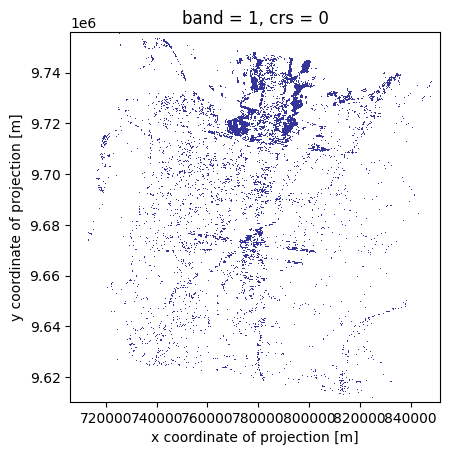

In [98]:
fig, ax = plt.subplots()
mask.plot.imshow(ax=ax, cmap="terrain_r", add_colorbar=False)
ax.set_aspect("equal")

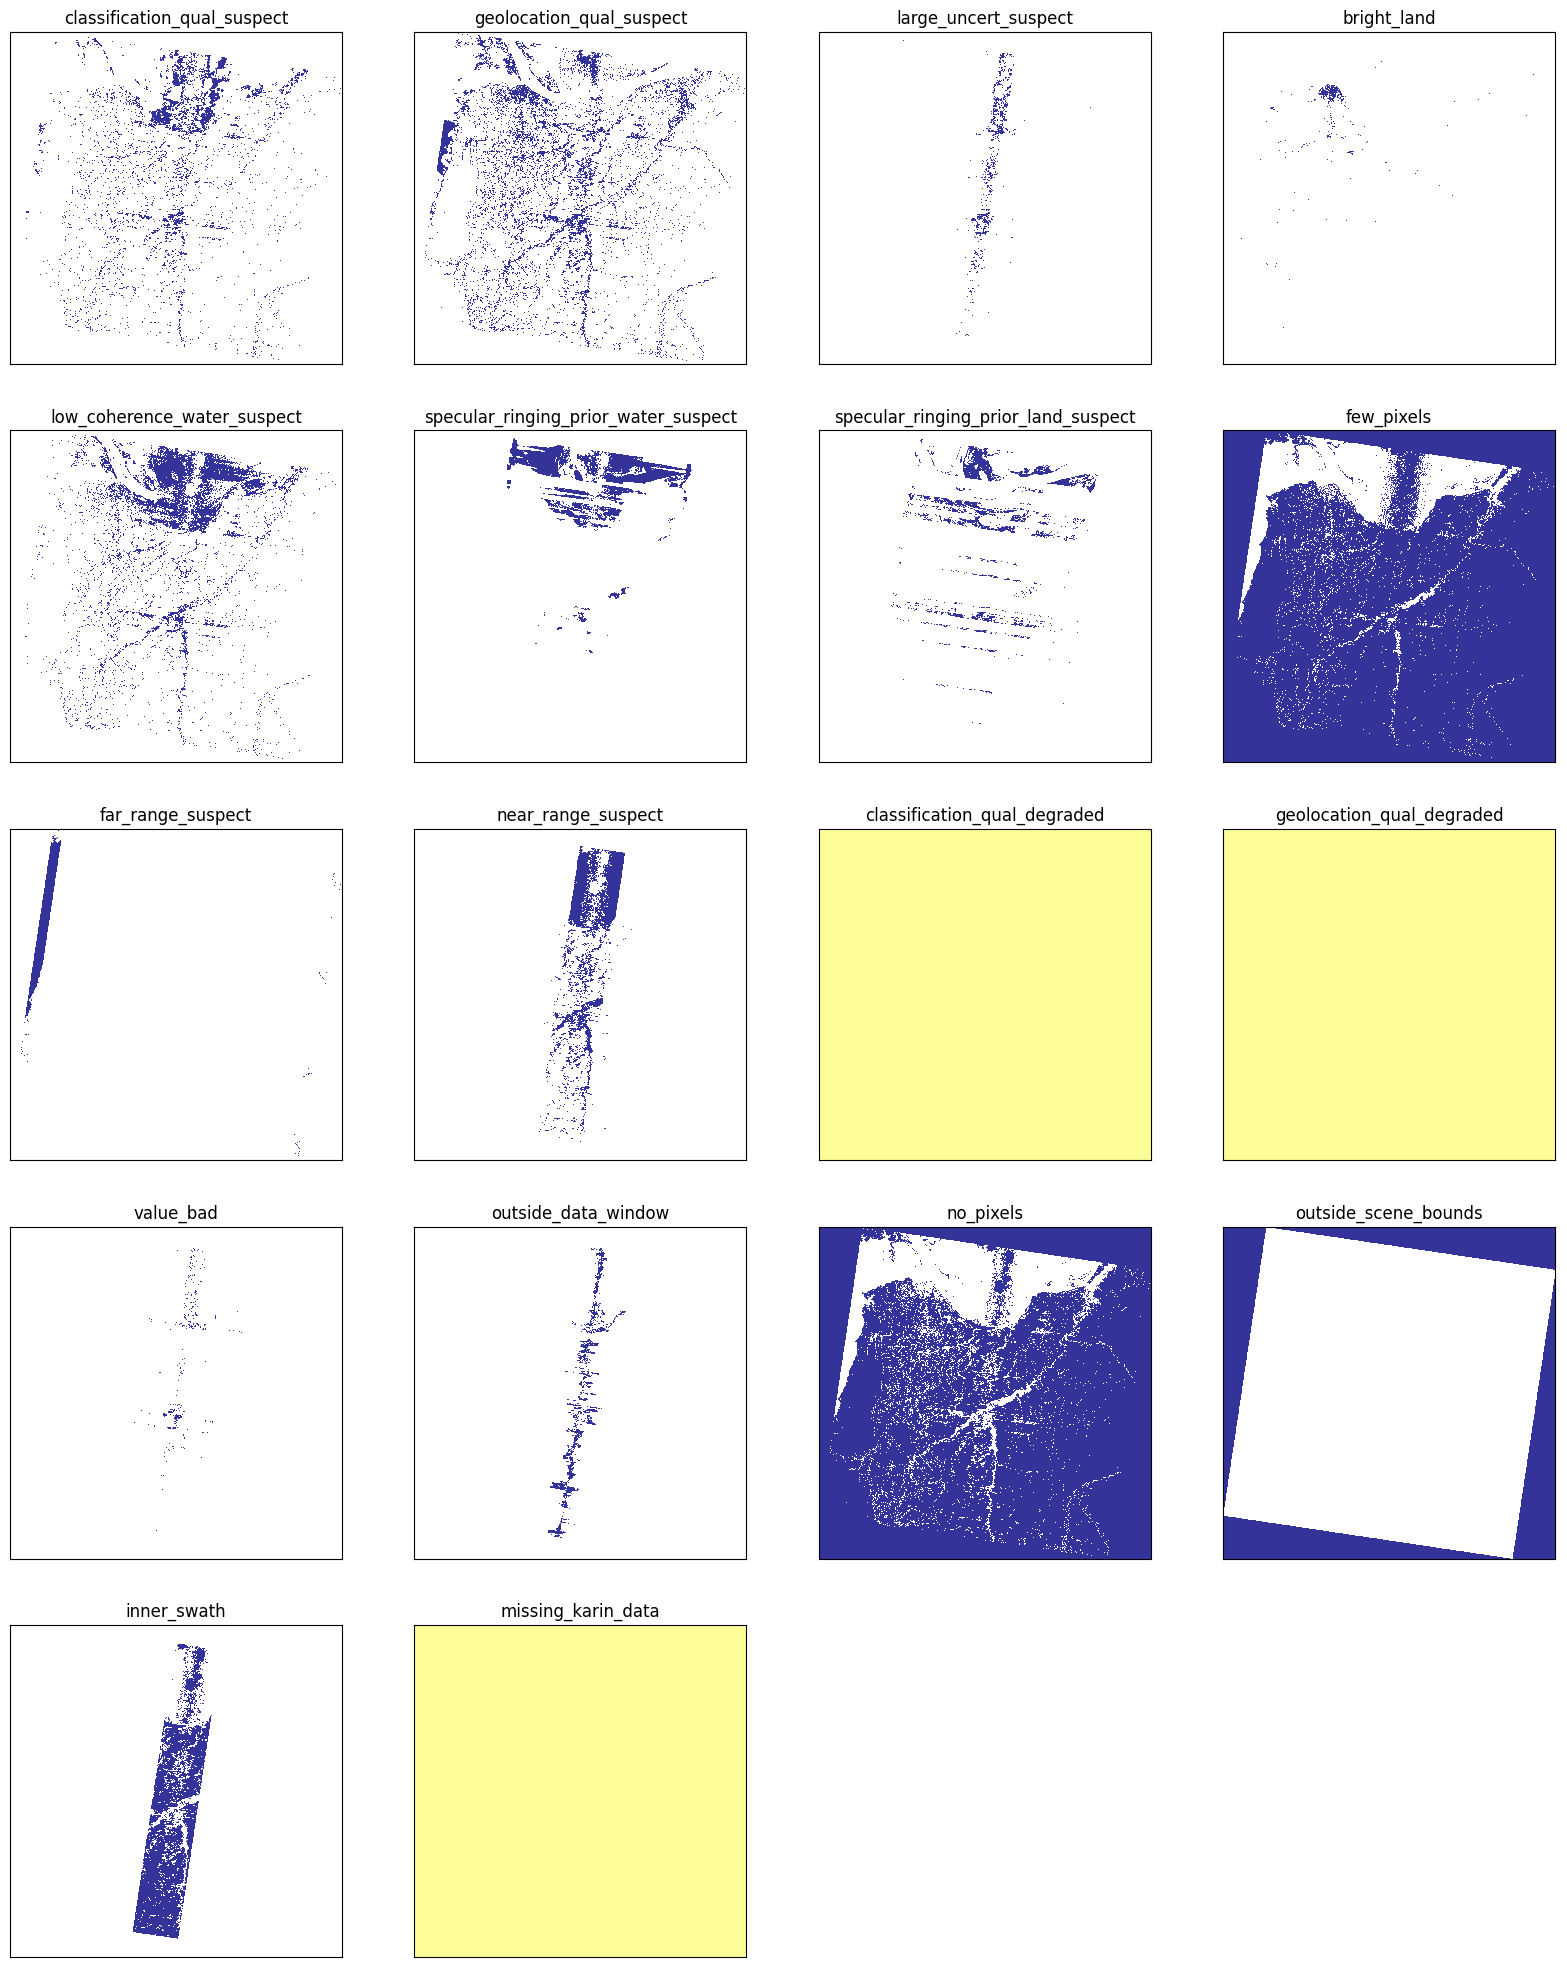

In [113]:
size = 5
cols = 4
rows = len(QUALITY_FLAGS) // cols + (len(QUALITY_FLAGS) % cols > 0)

fig, axs = plt.subplots(rows, cols, figsize=(size * cols, size * rows))

for ax, flag in zip(axs.flat, QUALITY_FLAGS, strict=False):
    masked = mask_by_flags(qual_bit, flags=[flag])
    masked.plot.imshow(ax=ax, cmap="terrain_r", add_colorbar=False)
    ax.set_title(flag)
    ax.set_aspect("equal")

for ax in axs.flat:
    # disable axis labels
    if ax.get_title() != "":
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.set_axis_off()

## Create Raster Mosaic

For the raster creation we have 4 main options:
* Create the raster "as-is"
* Create the raster using main quality flag (most users will do) to remove any suspect data
* Create the raster discarding non-observable areas (inner swath, outside scene)
* Fine tuning bit flags

Notice: The no-data (non-observable areas) will not penalize the metrics. All other masking will interfere mainly with the recall metric.




In [320]:
# First, let's get the reference mask
ref_mask = xrio.open_rasterio(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_ref_mask_svm-dell-mauricio.tif"
)

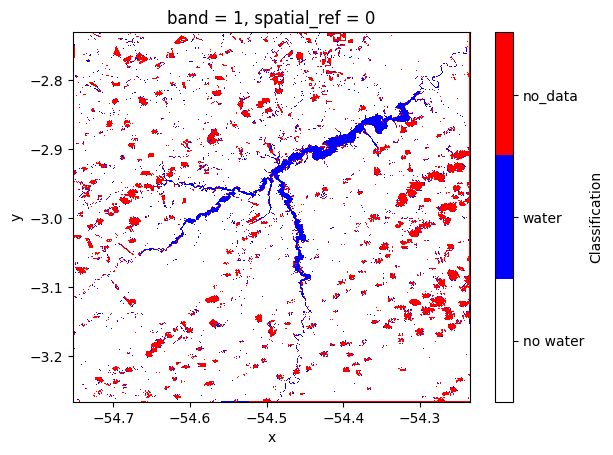

In [207]:
im = (
    ref_mask.coarsen(x=4, y=4, boundary="trim")
    .mean()
    .plot(cmap=ListedColormap(["white", "blue", "red"]))
)

cbar = im.colorbar
cbar.set_ticks([0.33, 1, 1.66])  # Set ticks at the actual values
cbar.set_ticklabels(["no water", "water", "no_data"])  # Descriptive
cbar


True
True


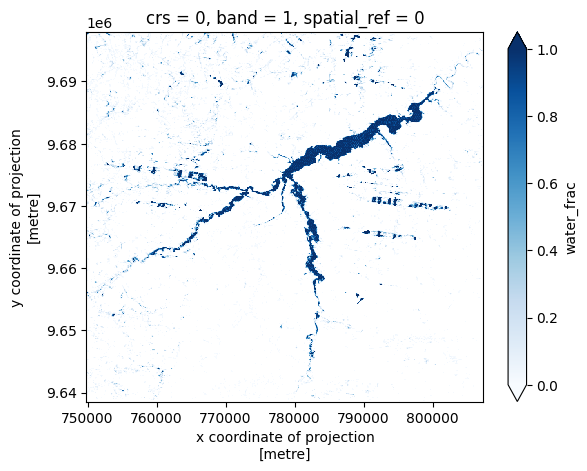

In [396]:
mosaic_ds, masks = create_raster_mosaic(
    mosaic_df,
    ref_date="2025-05-22",
    aoi=aoi,
    variable="water_frac",
    exclude_flags=None,
    exclude_no_data=True,
)


mosaic_array = mosaic_ds["water_frac"].mean(dim="idx")
mosaic_array.plot(cmap="Blues", vmin=0, vmax=1)

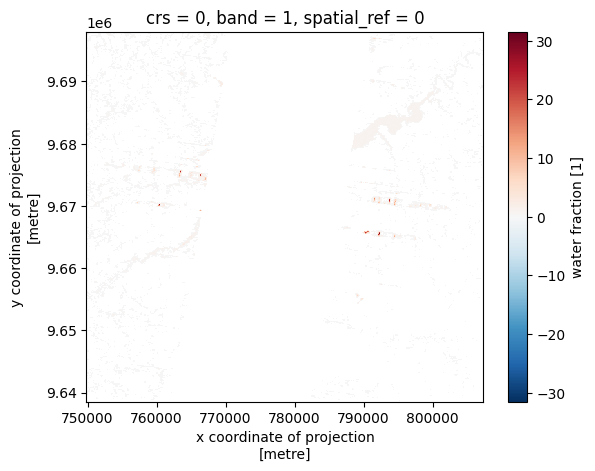

In [398]:
masks[0]["water_frac"].plot()

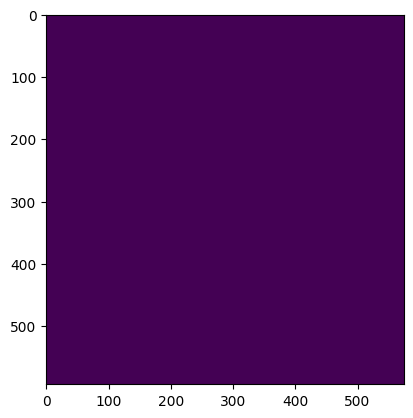

In [365]:
plt.imshow(masks[1])

In [278]:
from rasterio.enums import Resampling

In [282]:
mosaic_array.rio.write_crs("epsg:4326", inplace=True)

<xarray.DataArray 'water_frac' (y: 594, x: 573)> Size: 1MB
array([[0.5636078 , 1.0908515 , 0.11072178, ...,        nan,        nan,
               nan],
       [0.44252837, 0.97260773, 0.3741695 , ...,        nan,        nan,
               nan],
       [0.2835339 , 0.9174981 , 0.97362   , ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(594, 573), dtype=float32)
Coordinates:
    band         int64 8B 1
    crs          int64 8B 0
  * x            (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y            (y) float64 5kB -2.731 -2.732 -2.733 ... -3.264 -3.265 -3.266
    spatial_ref  int64 8B 0

## Calculate the Metric

In [321]:
ref_mask = ref_mask.rio.reproject_match(mosaic_array, resampling=Resampling.mode)

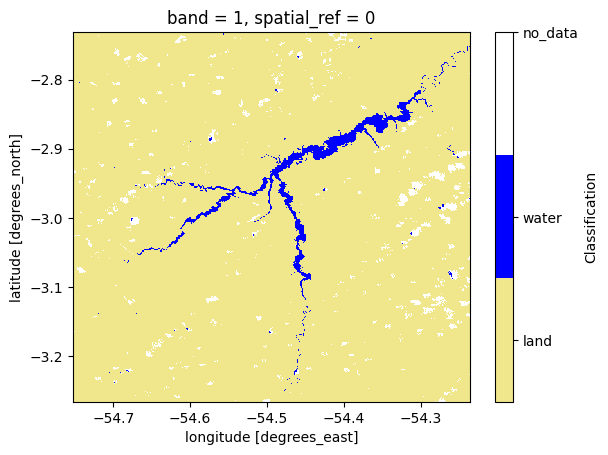

In [318]:
ref_mask = ref_mask.where(ref_mask != 2)  # remove no_data
im = ref_mask.plot(cmap=ListedColormap(["khaki", "blue"]))
cbar = im.colorbar
cbar.set_ticks([0.25, 0.75, 1.5])  # Set ticks at the actual values
cbar.set_ticklabels(["land", "water", "no_data"])  # Descriptive

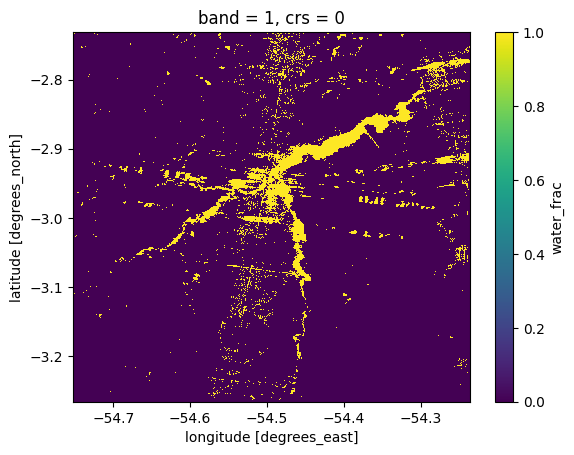

In [346]:
mosaic_array = (mosaic_array.fillna(0) > 0.5).astype(int)
mosaic_array.plot(vmin=0, vmax=1)

In [337]:
from swot_toolkit.metrics import calc_metrics

In [347]:
calc_metrics(ref_mask.squeeze(), mosaic_array)

{'accuracy': 0.9541503549863977,
 'precision': 0.3170117781155015,
 'recall': 0.8904749199573105,
 'f1': 0.46756794620341835,
 'kappa': 0.44920142222864523,
 'coverage': 1.0}

## Mask bit-flags accordingly

First experiment is remove all no-data from the prediction

### Toy samples for the Metrics

In [182]:
from sklearn.metrics import (
    cohen_kappa_score,
    f1_score,
    jaccard_score,
    precision_score,
    recall_score,
)


In [175]:
ref_mask = [0, 0, 0, 1, 1, 1, 0, 0, 0, 1]

all_true = [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
all_false = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

bad_mask = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
good_mask = [0, 0, 0, 1, 1, 1, 0, 0, 0, 0]


In [183]:
(
    cohen_kappa_score(ref_mask, all_true),
    jaccard_score(ref_mask, all_true),
    f1_score(ref_mask, all_true),
    precision_score(ref_mask, all_true),
    recall_score(ref_mask, all_true),
)

(-0.20689655172413768, 0.3, 0.46153846153846156, 0.3333333333333333, 0.75)

In [186]:
(
    cohen_kappa_score(ref_mask, all_false),
    jaccard_score(ref_mask, all_false),
    f1_score(ref_mask, all_false),
    # precision_score(ref_mask, all_false),
    recall_score(ref_mask, all_false),
)

(0.0, 0.0, 0.0, 0.0)

In [187]:
(
    cohen_kappa_score(ref_mask, bad_mask),
    jaccard_score(ref_mask, bad_mask),
    f1_score(ref_mask, bad_mask),
    precision_score(ref_mask, bad_mask),
    recall_score(ref_mask, bad_mask),
)

(-0.3999999999999999, 0.125, 0.2222222222222222, 0.2, 0.25)

In [190]:
(
    cohen_kappa_score(ref_mask, good_mask),
    jaccard_score(ref_mask, good_mask),
    f1_score(ref_mask, good_mask),
    precision_score(ref_mask, good_mask),
    recall_score(ref_mask, good_mask),
)

(0.7826086956521738, 0.75, 0.8571428571428571, 1.0, 0.75)

In [213]:
# Testing imbalanced data effect
# Here we have 1 error in a 40% water scene
(
    cohen_kappa_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 2],
    ),
    jaccard_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
    ),
    f1_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
    ),
    precision_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
    ),
    recall_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
    ),
)

(0.8076923076923077, 0.75, 0.8571428571428571, 1.0, 0.75)

In [193]:
# And here we have 1 error in a 20% water scene
(
    cohen_kappa_score(
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    ),
    jaccard_score(
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    ),
    f1_score(
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    ),
    precision_score(
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    ),
    recall_score(
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    ),
)

(0.6153846153846154, 0.5, 0.6666666666666666, 1.0, 0.5)

In [214]:
# What if we have a 3 class problem, where one sensor does not assign 0 (land), nor 1(water),
# but instead 2 (invalid pixel)

# The kappa score remains the same
cohen_kappa_score(
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 2],
)


0.8076923076923077

In [334]:
# Let's check F1
y_true = [0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
y_pred = [0, 0, 0, 1, 1, 1, 0, 0, 0, 1]
y_pred_no_data = [0, 0, 0, 1, 1, 1, 0, 0, 0, 2]


f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average="micro")
f1_no_data = f1_score(y_true, y_pred_no_data, labels=[0, 1, 2], average="micro")
f1_no_data_2 = f1_score(y_true, y_pred_no_data, labels=[0, 1], average="micro")

precision = precision_score(y_true, y_pred, labels=[0, 1, 2], average="micro")
precision_no_data = precision_score(y_true, y_pred_no_data, labels=[0, 1, 2], average="micro")
precision_no_data_2 = precision_score(y_true, y_pred_no_data, labels=[0, 1], average="micro")

recall = recall_score(y_true, y_pred, labels=[0, 1, 2], average="micro")
recall_no_data = recall_score(y_true, y_pred_no_data, labels=[0, 1, 2], average="micro")
recall_no_data_2 = recall_score(y_true, y_pred_no_data, labels=[0, 1], average="micro")


print("F1 when it misses water as land:", f1)
print("F1 when it misses water as no_data:", f1_no_data)
print("F1 when it misses water as no_data, but 2 is not in labels:", f1_no_data_2)

print("Precision when it misses water as land:", precision)
print("Precision when it misses water as no_data:", precision_no_data)
print("Precision when it misses water as no_data, but 2 is not in labels:", precision_no_data_2)

print("Recall when it misses water as land:", recall)
print("Recall when it misses water as no_data:", recall_no_data)
print("Recall when it misses water as no_data, but 2 is not in labels:", recall_no_data_2)


F1 when it misses water as land: 0.9
F1 when it misses water as no_data: 0.9
F1 when it misses water as no_data, but 2 is not in labels: 0.9473684210526315
Precision when it misses water as land: 0.9
Precision when it misses water as no_data: 0.9
Precision when it misses water as no_data, but 2 is not in labels: 1.0
Recall when it misses water as land: 0.9
Recall when it misses water as no_data: 0.9
Recall when it misses water as no_data, but 2 is not in labels: 0.9


Bottom line, when it predicts number 2 (no-data) and 2 is not in the valid labels, the PRECISION is not penalized, because it didnt said it was water, but RECALL is penalized, because it misses the water.

Great question — and your intuition is on point. What you’re seeing is a *side effect* of how `f1_score` in scikit‑learn interprets the `labels=` argument together with `average="micro"`. Below I’ll unpack precisely why the last result jumps to \~0.947 when you remove class `2`, and then suggest metrics that fit a water/land/no‑data mask comparison (including when “no‑data” should be penalized less than “land”).

---

## Why does removing `2` from `labels` change micro‑F1?

### Key behavior (scikit‑learn)

When you pass `labels=[...]` and `average="micro"`:

* scikit‑learn **only** aggregates true positives (TP), false positives (FP), and false negatives (FN) **for the listed labels**.
* A sample whose **true label** is in `labels`, but whose **predicted label** is *not* in `labels`, still counts as a **false negative** for its true class — but **no false positive is added** to any class (because the predicted class is excluded).

This “one‑sided” accounting is the root cause of your different F1 values.

---

## Walk‑through with your toy example

```
y_true         = [0,0,0,1,1,1,0,0,0,1]          (6 zeros, 4 ones)
y_pred         = [0,0,0,1,1,1,0,0,0,0]          (misses the last 1 as 0)
y_pred_no_data = [0,0,0,1,1,1,0,0,0,2]          (misses the last 1 as 2)
```

Recall the micro‑F1 formula (for single‑label classification):

$$
F1_{\text{micro}}=\frac{2\cdot TP}{2\cdot TP + FP + FN}.
$$

---

### Case A — “water→land” error

`f1_score(y_true, y_pred, labels=[0,1], average="micro")`

* There is 1 error (index 9): true `1` predicted `0`.
* Aggregated over labels {0,1}:

  * $TP=9$ (the first 9 are correct)
  * $FP=1$ (predicted `0` where true is `1`)
  * $FN=1$ (true `1` missed)
* $F1_{\text{micro}}= 2\cdot 9/(18+1+1)=18/20=0.9$.

**Result:** `0.9` (matches your printout)

---

### Case B — “water→no\_data” with class 2 **included**

`f1_score(y_true, y_pred_no_data, labels=[0,1,2], average="micro")`

* Still 1 error (index 9): true `1` predicted `2`.
* Over labels {0,1,2}:

  * $TP=9$
  * $FP=1$ (for class `2`, since a `2` was predicted but never true)
  * $FN=1$ (missed the true `1`)
* $F1_{\text{micro}}= 18/20=0.9$.

**Result:** `0.9` (same as Case A)

---

### Case C — “water→no\_data” with class 2 **excluded**

`f1_score(y_true, y_pred_no_data, labels=[0,1], average="micro")`

* Now labels are {0,1} only.
* The misclassified sample at index 9 (true `1` → predicted `2`) is handled asymmetrically:

  * It **does** add **FN=1** for class `1` (true class is included).
  * It **does not** add any **FP** (predicted class `2` is excluded).
* Over labels {0,1}:

  * $TP=9$, $FP=0$, $FN=1$
* $F1_{\text{micro}}= 2\cdot 9/(18+0+1)=18/19\approx 0.947368$.

**Result:** `0.947368…` — higher because you removed the FP that would have been counted for class `2`.

> **Takeaway:** With `average="micro"`, **including** class `2` counts the mistake twice (as FP for `2` and FN for `1`), while **excluding** class `2` counts it once (only as FN for `1`). That’s why the score goes up when you remove `2` from `labels`.

---

## Is `average="weighted"` better for your use‑case?

Short answer: **Usually not on its own**, especially for remote‑sensing masks where **land dominates** and **water is sparse**.

* `average="weighted"` computes per‑class F1 and weights each by its **true support**. In your toy example (labels {0,1}):

  * Class 0 (land): precision=1.0, recall=1.0 → $F1_0=1.0$
  * Class 1 (water): precision=1.0, recall=3/4=0.75 → $F1_1=\frac{2\cdot 1\cdot 0.75}{1+0.75}=0.857142857$
  * Weighted F1 $=\frac{6\cdot 1.0+4\cdot 0.8571}{10}\approx 0.942857$.

This is close to 0.947, but conceptually **weighted F1 is dominated by the majority class (land)**. In typical scenes where water may be 1–10% of pixels, weighted F1 can look excellent even if the water class is mediocre — which is risky if *water quality* is what you care about.

---

## Recommended evaluation for water/land/no‑data masks

Given your study aims (comparing SWOT‑derived masks with optical products and dealing with class imbalance), I’d suggest a two‑ (or three‑) track evaluation rather than leaning on `micro` vs `weighted` side effects:

### 1) **Quality on the *valid* domain (ignore “no‑data”)**

Evaluate water/land quality **only where both masks are valid**. This answers: *“When both sensors provide a decision, how good is the decision?”*

* **How:** mask out any pixel where **either** product is `no_data`, then compute:

  * Per‑class **precision/recall**, **F1 (Dice)** for **water** (report land too for completeness).
  * Or **IoU** (Jaccard) for water. (Relationship: $F1 = \frac{2\cdot IoU}{1+IoU}$.)
* **Why:** This avoids inflating/deflating scores because a sensor withheld a decision. It is the fairest apples‑to‑apples measure of classification *quality*.
* **Caveat:** A method could look perfect here while declining to classify a lot of pixels. So pair it with coverage (next item).

### 2) **Coverage / Validity (how often you abstain)**

Report how much of the scene is actually labeled by each product.

* **Metrics to add:**

  * **Valid fraction** = % of pixels not flagged `no_data`.
  * **Conditional invalid rates** (penalize asymmetrically if you want):

    * $\text{% true‑water predicted as no_data}$
    * $\text{% true‑land predicted as no_data}$
* **Composite option:** If you want a *single* number that “penalizes but not as much,” use
  **Effective‑F1** = $F1_{\text{water (valid)}} \times \text{Valid fraction}$.
  This is 1.0 only if you’re both accurate *and* covering everything; predicting a lot of `no_data` reduces the score but less harshly than mislabeling water as land.

### 3) *(Optional)* 3‑class analysis with a **custom cost matrix**

If you explicitly want to treat **water→no‑data** (less severe) vs **water→land** (more severe), define costs, e.g.:

* $C(\text{water}\to\text{land})=1.0$
* $C(\text{water}\to\text{no\_data})=0.5$
* $C(\text{land}\to\text{no\_data})=0.25$, etc.

Then compute a **cost‑sensitive accuracy** or **expected cost** from the 3×3 confusion matrix. This is more transparent than relying on `labels=[0,1]` with `average="micro"`, which incidentally dials down the penalty but in a way that depends on scikit‑learn’s internal accounting rather than your scientific priorities.

### 4) **Chance‑corrected agreement (Kappa) for imbalanced scenes**

Because water is often a minority class, reporting **Cohen’s kappa** alongside F1/IoU helps account for agreement “by chance” and is explicitly part of your project’s plan for model agreement under class imbalance. (In your project write‑up, kappa is proposed to measure agreement between masks and highlighted as more informative than raw agreement when classes are imbalanced. ) For completeness, your abstract also frames a validation step against higher‑quality reference data, which is where per‑class F1/IoU and kappa should ultimately be computed.&#x20;

---

## A tiny, concrete example (numbers you can verify)

Using the “water→no‑data” case (`y_pred_no_data`) and **ignoring no‑data** by filtering out any pixel where either side is `2`:

* Only the first 9 samples remain, and they’re all correct → **F1 (water, valid‑only) = 1.0**.
* **Valid fraction** = 9/10 = 0.9.
* **Effective‑F1** = 1.0 × 0.9 = **0.9**.

Compare to “water→land” case (`y_pred`):

* All 10 pixels are valid, but there is 1 misclassification.
* On valid‑only domain (same as full domain), **F1 (water) = 0.8571**, **Valid fraction = 1.0**, **Effective‑F1 = 0.8571**.

So, with this pair of metrics you get exactly the behavior you said you wanted:

* Predicting **no‑data** instead of the wrong class is **penalized**, but **less** than labeling water as land (0.90 vs 0.86 in this toy setup).

---

## Practical checklist for your study

1. **Always publish the confusion matrix.**

   * 2‑class (water/land) on the **AND‑valid** domain.
   * Optionally 3‑class to inspect how often `no_data` is used and on which truths.

2. **Report (at minimum):**

   * **F1 (Dice) and IoU for the water class** on the valid domain (+ land for completeness).
   * **Valid fraction** (coverage), and **conditional invalid rates** (true‑water → no‑data; true‑land → no‑data).

3. **Add Kappa** for agreement under imbalance (as planned in your project).&#x20;

4. **If you must compress to one number**, prefer a **composite** you control (e.g., Effective‑F1) or a **cost‑sensitive score**, rather than relying on `labels=[0,1]` with micro averaging.

---

## Bottom line

* The jump to **0.947** happens because excluding class `2` drops the **FP** that would otherwise be attributed to class `2`, while keeping the **FN** for class `1`. Micro‑F1 uses $2TP/(2TP+FP+FN)$, so the denominator gets **smaller by 1**, and the score rises.
* **`average="weighted"` alone is not ideal** for your masks, because it will be dominated by **land** and can hide poor **water** performance.
* For your use‑case, I recommend: **(i)** compute water/land metrics on the **AND‑valid** domain (F1/IoU), **(ii)** report **coverage and invalid rates**, and **(iii)** optionally use a **cost‑sensitive** 3‑class score to encode the “no‑data is bad but less bad than land” rule. Add **kappa** to reflect chance‑corrected agreement, as you already plan.

If you’d like, I can sketch a small helper that builds these reports (confusion matrices + F1/IoU + coverage + optional cost‑sensitive score) from your masks so everything is computed consistently across scenes.


In [ ]:

    precision_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 2],
        average=None,
    ),
    recall_score(
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 2],
        average=None,
    ),
)